<h1 align="center"> Tarea 3
<h2 align="center">  Integrantes: Bastián Araneda, Isaías Gómez, Junwei He y Nicolás Pacheco.
<h3 align="center"> IN4151-2 - Ingeniería de la Información
<h3 align="center"> Otoño 2023

---

# Introducción

# LECTURA DE BASE DE DATOS

Primero que todo, se debe importar las librerías a utilizar:

In [ ]:
# Importamos librerias a utilizar
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn import datasets
import matplotlib.pyplot as plt

!python -m pip install ChernoffFace
from ChernoffFace import *

A continuación, se carga la base de datos:

In [ ]:
# CARGAR DATOS USANDO COLAB
df = pd.read_csv("https://raw.githubusercontent.com/JunTierSS/TICS/main/202306122225CC8792F4D39D169B__credits.csv")
df

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,7.0,11.27,4.0,809.98,26.822620,No,80.415295,High_spent_Small_value_payments,312.494089,1
1,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,8.0,11.27,4.0,809.98,22.537593,No,178.344067,Low_spent_Small_value_payments,244.565317,1
2,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,1.0,7.42,2.0,605.03,38.550848,No,40.391238,High_spent_Large_value_payments,484.591214,1
3,0x1612,CUS_0x21b1,May,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,1.0,6.42,2.0,605.03,34.977895,No,130.115420,Low_spent_Small_value_payments,444.867032,1
4,0x1613,CUS_0x21b1,June,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,0.0,5.42,2.0,605.03,33.381010,No,43.477190,High_spent_Large_value_payments,481.505262,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28916,0x255c8,CUS_0xa568,March,t Pascalei,40,520-28-2763,Scientist,120009.32,10242.776667,5,...,2.0,6.75,0.0,446.51,23.531367,No,559.479655,Low_spent_Large_value_payments,504.269659,1
28917,0x255cb,CUS_0xa568,June,t Pascalei,40,520-28-2763,_______,120009.32,10242.776667,5,...,-1.0,6.75,0.0,446.51,36.410315,No,204.183982,!@9#%8,829.565332,1
28918,0x255d3,CUS_0x701f,February,Kazunorig,24,549-24-1350,Lawyer,59868.93,5111.077500,4,...,11.0,6.09,0.0,417.72,30.978905,No,10000.000000,Low_spent_Medium_value_payments,169.555805,1
28919,0x255de,CUS_0xb80d,January,Alex Frewt,31,713-24-3856,Developer,28796.82,2378.735000,6,...,21.0,2.78,8.0,2382.35,35.168085,Yes,226.655273,Low_spent_Medium_value_payments,208.983007,0


Primero vamos a analizar el data frame limpiando data que contenga NA's.

# FEATURE CLEANING




Featuring Engeneering es un marco metodológico que permite diseñar y generar conjuntos de información y discriminantes atributos o características para algoritmos de Machine Learning, a través de la ejecución de tareas que permitan la explotación de información y conocimiento pertenecientes a un dominio específico para definir, extraer y evaluar adecuadamente un conjunto de variables que brinden soporte de información confiable para la elaboración del modelo buscado.

In [ ]:
#Calcula y muestra la cantidad total de valores nulos en el DataFrame "df".
val_null_train=df.isnull()
print("Total de datos vacíos = ", val_null_train.sum().sum())

Total de datos vacíos =  0


# FEATURING GENERATION

Es el proceso de transformación de datos de entrada en un conjunto de características más significativas.

No se hace este proceso debido a que no es viable juntar variables binarias.


# FEATURING REDUCTION

Es el proceso de reducir la dimensionalidad de las variables manteniendo la información más relevante y significativa, algunas técnicas para esto es el análisis de componentes principales (PCA) o el análisis de discriminante lineal (LDA). (En este caso no se puede realizar este procedimiento debido a que es exclusivamente para variables continuas y para este caso son mayoritariamente binarias)

Las variables se agruparan en grandes grupos.


Factores de salud cardiovascular:
Presión arterial
Colesterol
Checkeo médico de colesterol
Índice de masa corporal
Fumador
Derrame cerebral
Presencia de enfermedades cardiacas  

Factores de estilo de vida saludable:
Si se ejercita físicamente
Si come frutas
Si come verduras
Consumo de alcohol

Acceso a la atención médica:
Cuenta con seguro de salud
Necesidad de ir al médico pero no poder pagar uno

Nivel socioeconómico:
Nivel de educación
Ingreso


Percepción y bienestar:
Percepción propia del nivel de salud
Días con estrés
Días con malestar físico
Dificultad para caminar

Factores demográficos:
Género
Edad

Enfermedades relacionadas con el corazón:
Presión arterial
Colesterol
Derrame cerebral
Presencia de enfermedades cardiacas

Hábitos de salud:
Si se ejercita físicamente
Si come frutas
Si come verduras
Consumo de alcohol

Donde finalmente se agrupa en 7 grandes grupos: HighBP, Veggies, NoDocbcCost, GenHlth, Sex, Age e Income (var independientes)



In [ ]:
#Reducción de la base a atributos escenciales
drop_list1 = ['ID','Name','Customer_ID','Month','Occupation','Changed_Credit_Limit','Amount_invested_monthly','SSN','Num_Credit_Inquiries','Credit_Utilization_Ratio','Payment_of_Min_Amount','Monthly_Balance','Interest_Rate','Num_of_Loan']
df = df.drop(drop_list1,axis = 1 )



In [ ]:
def transformar_valor(valor):
    if valor == 'Low_spent_Small_value_payments':
        return 0
    elif valor == 'Low_spent_Medium_value_payments':
        return 0
    elif valor == 'Low_spent_Large_value_payments':
        return 0
    elif valor == 'High_spent_Small_value_payments':
        return 1
    elif valor == "High_spent_Medium_value_payments":
        return 1
    elif valor == "High_spent_Large_value_payments":
        return 1
    else:
      return 2

# Aplicar el mapeo utilizando el método map()
df['Payment_Behaviour'] = df['Payment_Behaviour'].map(transformar_valor)


# EDA BÁSICO


 Un EDA (Exploratory Data Analysis) consiste en la exploración de datos interesantes entre las variables, ya sea medidas de tendencia central, correlaciones o histogramas que permiten la visualización de los datos en forma gráfica.


In [ ]:
#A continuación se muestra una tabla con todas las medidas importantes para cada variable:
df.describe()


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,Payment_Behaviour,Credit_Score
count,28921.000000,2.892100e+04,28921.000000,28921.000000,28921.000000,28921.000000,28921.000000,28921.000000,28921.000000,28921.000000
mean,28.134608,1.680772e+05,4101.377057,16.622109,23.096159,22.596694,31.504443,1587.542281,0.570727,0.379793
std,52.467059,1.402458e+06,3217.513938,115.176028,130.826302,16.616417,231.055651,1151.089586,0.629979,0.485344
min,-500.000000,7.005930e+03,319.556250,-1.000000,0.000000,-5.000000,-3.000000,0.230000,0.000000,0.000000
25%,24.000000,1.874308e+04,1567.786667,3.000000,4.000000,10.000000,8.000000,702.890000,0.000000,0.000000
50%,33.000000,3.730210e+04,3050.206667,6.000000,6.000000,18.000000,14.000000,1361.670000,0.000000,0.000000
75%,41.000000,7.013780e+04,5721.726667,8.000000,7.000000,31.000000,19.000000,2253.320000,1.000000,1.000000
max,99.000000,2.419806e+07,15167.180000,1794.000000,1499.000000,67.000000,4360.000000,4998.070000,2.000000,1.000000


In [ ]:
#Se explicita el promedio de cada variable
df.mean()

Age                           28.134608
Annual_Income             168077.209046
Monthly_Inhand_Salary       4101.377057
Num_Bank_Accounts             16.622109
Num_Credit_Card               23.096159
Delay_from_due_date           22.596694
Num_of_Delayed_Payment        31.504443
Outstanding_Debt            1587.542281
Payment_Behaviour              0.570727
Credit_Score                   0.379793
dtype: float64

In [ ]:
#Se explicita la mediana de cada variable
df.median()

Age                          33.000000
Annual_Income             37302.100000
Monthly_Inhand_Salary      3050.206667
Num_Bank_Accounts             6.000000
Num_Credit_Card               6.000000
Delay_from_due_date          18.000000
Num_of_Delayed_Payment       14.000000
Outstanding_Debt           1361.670000
Payment_Behaviour             0.000000
Credit_Score                  0.000000
dtype: float64

In [ ]:
#Se explicita la moda de cada variable
df.mode()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,Payment_Behaviour,Credit_Score
0,28.0,14208.865,3080.555,6.0,5.0,15.0,18.0,2089.58,0.0,0.0
1,NaN,15096.850,NaN,NaN,NaN,NaN,NaN,2370.05,NaN,NaN
2,NaN,15806.695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,16408.770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,17517.550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,17535.570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,29112.320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,32795.940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,33121.690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,39323.540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


MEDIDAS DE DISPERSION

In [ ]:
#Se muestra el rango de cada variable
df_range = df.max() - df.min()
df_range

Age                       5.990000e+02
Annual_Income             2.419106e+07
Monthly_Inhand_Salary     1.484762e+04
Num_Bank_Accounts         1.795000e+03
Num_Credit_Card           1.499000e+03
Delay_from_due_date       7.200000e+01
Num_of_Delayed_Payment    4.363000e+03
Outstanding_Debt          4.997840e+03
Payment_Behaviour         2.000000e+00
Credit_Score              1.000000e+00
dtype: float64

In [ ]:
#Luego. se muestran los cuartiles de cada variable
quartiles = df.quantile([0.25,0.5,0.75])
quartiles

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,Payment_Behaviour,Credit_Score
0.25,24.0,18743.075,1567.786667,3.0,4.0,10.0,8.0,702.89,0.0,0.0
0.50,33.0,37302.100,3050.206667,6.0,6.0,18.0,14.0,1361.67,0.0,0.0
0.75,41.0,70137.800,5721.726667,8.0,7.0,31.0,19.0,2253.32,1.0,1.0


In [ ]:
#Se muestra el Rango Intercuartilítico de cada variable
quartiles.loc["IQR"] = quartiles.loc[0.75] - quartiles.loc[0.25]
quartiles

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,Payment_Behaviour,Credit_Score
0.25,24.0,18743.075,1567.786667,3.0,4.0,10.0,8.0,702.89,0.0,0.0
0.5,33.0,37302.100,3050.206667,6.0,6.0,18.0,14.0,1361.67,0.0,0.0
0.75,41.0,70137.800,5721.726667,8.0,7.0,31.0,19.0,2253.32,1.0,1.0
IQR,17.0,51394.725,4153.940000,5.0,3.0,21.0,11.0,1550.43,1.0,1.0


In [ ]:
#Se muestra la varianza de cada variable
df.var()

Age                       2.752792e+03
Annual_Income             1.966888e+12
Monthly_Inhand_Salary     1.035240e+07
Num_Bank_Accounts         1.326552e+04
Num_Credit_Card           1.711552e+04
Delay_from_due_date       2.761053e+02
Num_of_Delayed_Payment    5.338671e+04
Outstanding_Debt          1.325007e+06
Payment_Behaviour         3.968734e-01
Credit_Score              2.355585e-01
dtype: float64

In [ ]:
#Se muestra la desviación estándar de cada variable
df.std()

Age                       5.246706e+01
Annual_Income             1.402458e+06
Monthly_Inhand_Salary     3.217514e+03
Num_Bank_Accounts         1.151760e+02
Num_Credit_Card           1.308263e+02
Delay_from_due_date       1.661642e+01
Num_of_Delayed_Payment    2.310557e+02
Outstanding_Debt          1.151090e+03
Payment_Behaviour         6.299789e-01
Credit_Score              4.853437e-01
dtype: float64

GRAFICOS DESCRIPTIVOS

<Axes: title={'center': 'Outstanding_Debt'}, xlabel='Credit_Score'>

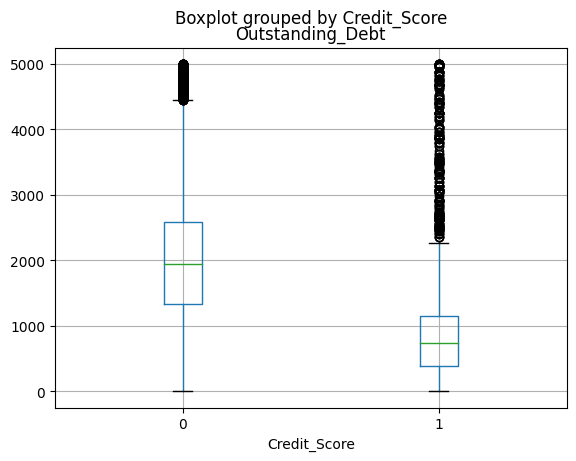

In [ ]:
#El siguiente gráfico muestra un diagrama de caja de la edad de las personas con y sin puntuacion de credito
df.boxplot(by="Credit_Score", column=["Outstanding_Debt"], grid=True)

<Axes: title={'center': 'Monthly_Inhand_Salary'}, xlabel='Credit_Score'>

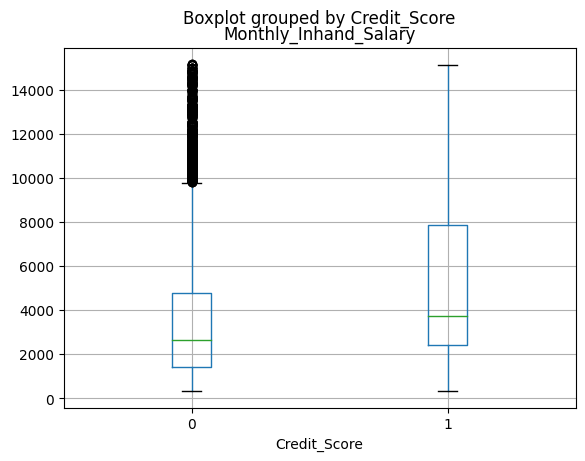

In [ ]:
#El siguiente gráfico muestra un diagrama de caja del nivel de colesterol de las personas con y sin diabetes
df.boxplot(by="Credit_Score", column=["Monthly_Inhand_Salary"], grid=True)

<Axes: xlabel='Credit_Score', ylabel='Age'>

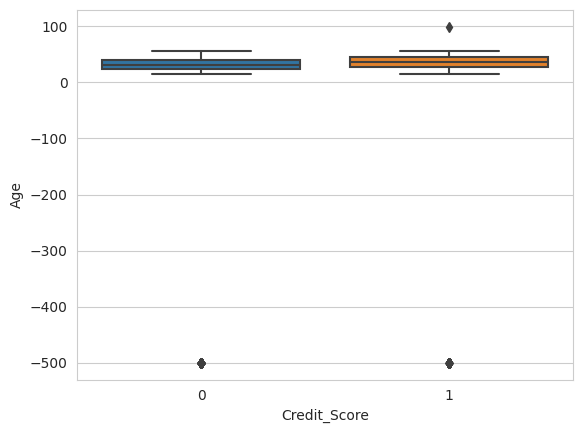

In [ ]:
sns.set_style("whitegrid")
sns.boxplot(x="Credit_Score", y="Age", data=df)

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Annual_Income'}>,
        <Axes: title={'center': 'Monthly_Inhand_Salary'}>],
       [<Axes: title={'center': 'Num_Bank_Accounts'}>,
        <Axes: title={'center': 'Num_Credit_Card'}>,
        <Axes: title={'center': 'Delay_from_due_date'}>],
       [<Axes: title={'center': 'Num_of_Delayed_Payment'}>,
        <Axes: title={'center': 'Outstanding_Debt'}>,
        <Axes: title={'center': 'Payment_Behaviour'}>],
       [<Axes: title={'center': 'Credit_Score'}>, <Axes: >, <Axes: >]],
      dtype=object)

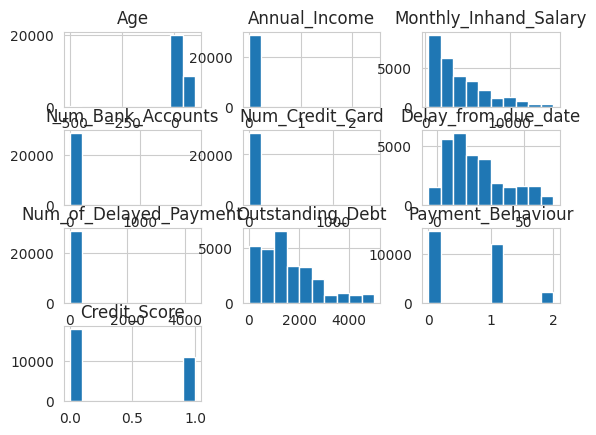

In [ ]:
#Se presentan histogramas de las distintas variables independientes según si las personas tienen o no diabetes
df.hist()

# EDA AVANZADO

In [ ]:
#Matriz de correlaciones según metodo de Pearson
df.corr(method="pearson")

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,Payment_Behaviour,Credit_Score
Age,1.000000,0.003658,0.020460,0.007085,-0.000509,-0.046045,-0.006660,-0.051498,0.002072,0.047005
Annual_Income,0.003658,1.000000,0.028463,0.001290,-0.001634,-0.010473,-0.006670,-0.005477,0.002917,0.009990
Monthly_Inhand_Salary,0.020460,0.028463,1.000000,-0.003357,-0.005123,-0.288844,0.000378,-0.320926,0.183636,0.293367
Num_Bank_Accounts,0.007085,0.001290,-0.003357,1.000000,0.002178,0.011619,-0.003331,0.017003,-0.002325,-0.014355
Num_Credit_Card,-0.000509,-0.001634,-0.005123,0.002178,1.000000,0.014134,-0.000767,0.016601,-0.008769,-0.014504
Delay_from_due_date,-0.046045,-0.010473,-0.288844,0.011619,0.014134,1.000000,0.008554,0.579904,-0.060231,-0.546666
Num_of_Delayed_Payment,-0.006660,-0.006670,0.000378,-0.003331,-0.000767,0.008554,1.000000,0.011235,-0.000605,-0.008527
Outstanding_Debt,-0.051498,-0.005477,-0.320926,0.017003,0.016601,0.579904,0.011235,1.000000,-0.073604,-0.531905
Payment_Behaviour,0.002072,0.002917,0.183636,-0.002325,-0.008769,-0.060231,-0.000605,-0.073604,1.000000,0.103154
Credit_Score,0.047005,0.009990,0.293367,-0.014355,-0.014504,-0.546666,-0.008527,-0.531905,0.103154,1.000000


In [ ]:
#Matriz de correlaciones según metodo de Spearman
df.corr(method='spearman')

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,Payment_Behaviour,Credit_Score
Age,1.000000,0.103045,0.102287,-0.211397,-0.163817,-0.208484,-0.211675,-0.248153,0.026501,0.219797
Annual_Income,0.103045,1.000000,0.974724,-0.310362,-0.244159,-0.285618,-0.306179,-0.337891,0.254433,0.282151
Monthly_Inhand_Salary,0.102287,0.974724,1.000000,-0.312990,-0.244351,-0.287832,-0.310145,-0.341631,0.262165,0.283056
Num_Bank_Accounts,-0.211397,-0.310362,-0.312990,1.000000,0.490483,0.642231,0.646875,0.612108,-0.077231,-0.517152
Num_Credit_Card,-0.163817,-0.244159,-0.244351,0.490483,1.000000,0.517883,0.476942,0.507713,-0.066355,-0.495353
Delay_from_due_date,-0.208484,-0.285618,-0.287832,0.642231,0.517883,1.000000,0.621596,0.624153,-0.070787,-0.590745
Num_of_Delayed_Payment,-0.211675,-0.306179,-0.310145,0.646875,0.476942,0.621596,1.000000,0.606480,-0.079471,-0.493420
Outstanding_Debt,-0.248153,-0.337891,-0.341631,0.612108,0.507713,0.624153,0.606480,1.000000,-0.091621,-0.598725
Payment_Behaviour,0.026501,0.254433,0.262165,-0.077231,-0.066355,-0.070787,-0.079471,-0.091621,1.000000,0.115309
Credit_Score,0.219797,0.282151,0.283056,-0.517152,-0.495353,-0.590745,-0.493420,-0.598725,0.115309,1.000000


In [ ]:
#Matriz de covarianzas
df.cov()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,Payment_Behaviour,Credit_Score
Age,2752.792288,2.691844e+05,3.453946e+03,42.813386,-3.492405,-40.142460,-8.074076e+01,-3.110192e+03,0.068470,1.196973
Annual_Income,269184.366110,1.966888e+12,1.284373e+08,208400.483192,-299749.906701,-244066.892292,-2.161474e+06,-8.842507e+06,2577.160067,6800.099789
Monthly_Inhand_Salary,3453.946323,1.284373e+08,1.035240e+07,-1243.913851,-2156.248470,-15442.602699,2.806996e+02,-1.188595e+06,372.224529,458.122521
Num_Bank_Accounts,42.813386,2.084005e+05,-1.243914e+03,13265.517463,32.818427,22.235798,-8.863288e+01,2.254271e+03,-0.168690,-0.802463
Num_Credit_Card,-3.492405,-2.997499e+05,-2.156248e+03,32.818427,17115.521424,30.725539,-2.318962e+01,2.499955e+03,-0.722759,-0.920927
Delay_from_due_date,-40.142460,-2.440669e+05,-1.544260e+04,22.235798,30.725539,276.105320,3.284221e+01,1.109181e+04,-0.630499,-4.408682
Num_of_Delayed_Payment,-80.740761,-2.161474e+06,2.806996e+02,-88.632882,-23.189622,32.842214,5.338671e+04,2.988225e+03,-0.088117,-0.956252
Outstanding_Debt,-3110.192048,-8.842507e+06,-1.188595e+06,2254.270999,2499.955031,11091.808960,2.988225e+03,1.325007e+06,-53.374668,-297.161653
Payment_Behaviour,0.068470,2.577160e+03,3.722245e+02,-0.168690,-0.722759,-0.630499,-8.811682e-02,-5.337467e+01,0.396873,0.031540
Credit_Score,1.196973,6.800100e+03,4.581225e+02,-0.802463,-0.920927,-4.408682,-9.562518e-01,-2.971617e+02,0.031540,0.235558


In [ ]:
#Distancia euclidiana
one_array = df[df['Credit_Score'] == 1].drop(['Credit_Score'], axis=1).mean().to_numpy()
zero_array = df[df['Credit_Score'] == 0].drop(['Credit_Score'], axis=1).mean().to_numpy()


print('Distancia entre Diabetes1 y Diabetes0:', np.linalg.norm(one_array - zero_array))
#No se usará esto ya que no se puede hacer el PCA

Distancia entre Diabetes1 y Diabetes0: 28960.92348544353


<Axes: >

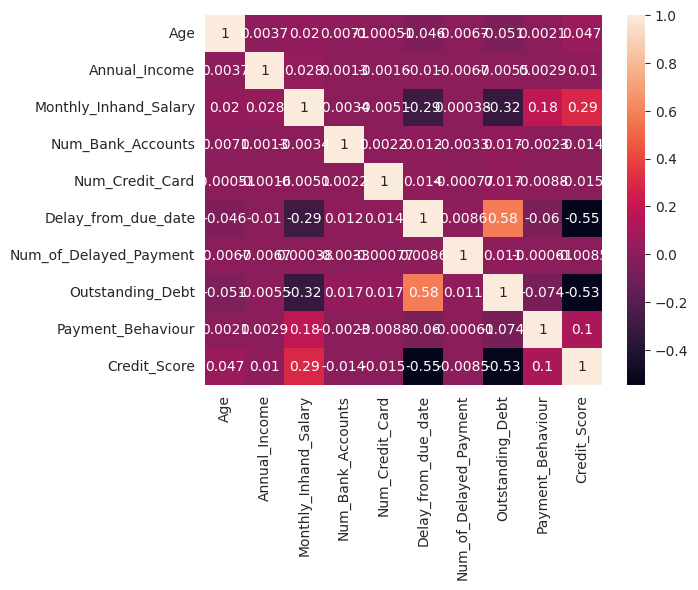

In [ ]:
# Heatmap de matriz de correlacion de pearson
corr_matrix = df.corr(method='pearson')
sns.heatmap(corr_matrix, annot=True)

<Axes: >

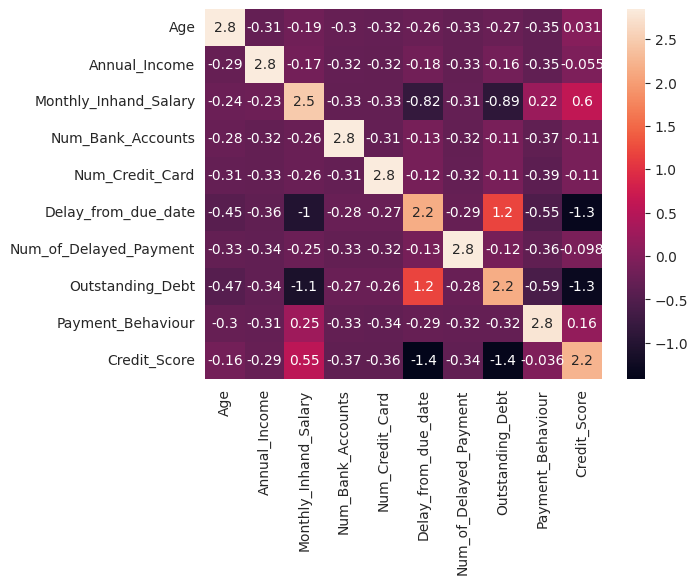

In [ ]:
#Heatmap de la matriz de correlaciones normalizada
corr_matrix_norm = (corr_matrix - corr_matrix.mean()) / corr_matrix.std()
sns.heatmap(corr_matrix_norm, annot=True)

In [ ]:
import plotly.express as px
import pandas as pd

# Features
features = df.columns.tolist()
one = list(df[df['Credit_Score'] == 1].drop(['Credit_Score'], axis=1).mean())
cero = list(df[df['Credit_Score'] == 0].drop(['Credit_Score'], axis=1).mean())


In [ ]:
#radar chart
import plotly.graph_objects as go

fig = go.Figure(data=go.Scatterpolar(
  r=one,
  theta=features,
  fill='toself',
))

fig.update_layout(
  title='Diabetes Radar Chart',
  polar=dict(
    radialaxis=dict(
      visible=True
    ),
  ),
  showlegend=False
)

fig.show()

# Modelos de Clasificación

Machine learning corresponde al proceso que consiste en entrenar un modelo utilizando un conjunto de datos de entrenamiento, el cual consiste en ejemplos previamente etiquetados o datos históricos. El modelo utiliza estos datos para aprender patrones y reglas subyacentes, y luego puede aplicar ese conocimiento a nuevos datos no etiquetados para hacer predicciones o tomar decisiones.

## Definición de variables

In [ ]:
from sklearn.model_selection import train_test_split

# Definimos las variables independientes y la variable dependiente
X = df.drop(['Credit_Score'], axis=1).to_numpy()
y = df['Credit_Score'].to_numpy()

# Dividimos en sets de entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

## Modelo 1 arboles:



 Bajo este modelo, lo que haremos será crear estructuras en forma de árbol que representan decisiones y sus posibles consecuencias. Cada nodo interno del árbol representa una característica, cada rama representa una decisión y cada hoja representa una clase o resultado. Gracias a este sistema podremos interpretar y analizar el comportamiento de los datos de una mejor forma.

In [ ]:
# Importamos los arboles de sklearn
from sklearn import tree

# Creamos el arbol de decision y lo entrenamos
dt_clf = tree.DecisionTreeClassifier()
dt_clf = dt_clf.fit(X_train, y_train)

# Clasificamos el set de testeo y visualizamos
dt_pred = dt_clf.predict(X_test)

print('Predicciones:', dt_pred)
print('\nReales:', y_test)

Predicciones: [1 1 0 ... 0 0 0]

Reales: [1 1 0 ... 0 0 0]


## Modelo 2 bayes:

Este modelo se basa en el teorema de Bayes y asume la independencia condicional entre las características, es decir, el modelo calcula la probabilidad de que un punto de datos pertenezca a una clase en función de la probabilidad de las características observadas.


In [ ]:
# Importamos el modelo
from sklearn.naive_bayes import GaussianNB

# Creamos el modelo y lo entrenamos
gnb_clf = GaussianNB()
gnb_clf.fit(X_train, y_train)

# Clasificamos el set de testeo y visualizamos
gnb_pred = gnb_clf.predict(X_test)

print('Predicciones:', gnb_pred)
print('\nReales:', y_test)

Predicciones: [1 1 0 ... 0 0 0]

Reales: [1 1 0 ... 0 0 0]


# Modelo 3 KNN:

In [ ]:
# Creamos el modelo y lo entrenamos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# 81 81 87 80 81 77
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train, y_train)

# Clasificamos el set de testeo y visualizamos
neigh_pred = neigh.predict(X_test)

print('Performance metrics for Sigmoid Kernel:\n', classification_report(y_test, neigh_pred))

Performance metrics for Sigmoid Kernel:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93      3600
           1       0.88      0.90      0.89      2185

    accuracy                           0.91      5785
   macro avg       0.91      0.91      0.91      5785
weighted avg       0.91      0.91      0.91      5785



<ipython-input-44-6277759198ad>:20: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



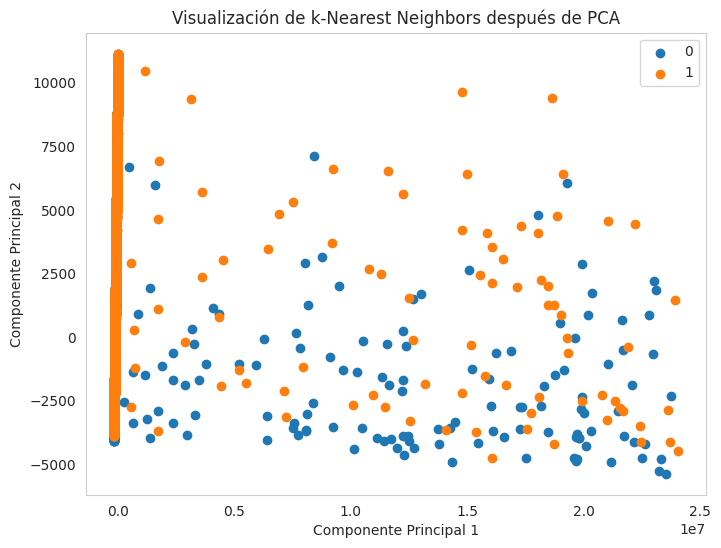

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# Aplicar PCA a los datos originales
#y_pred = neigh.predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# Mapear las etiquetas de clase a números
labels = np.unique(y_train)
label_mapping = {label: i for i, label in enumerate(labels)}
y_mapped = np.array([label_mapping[label] for label in y_train])


# Crear la figura y los ejes
plt.figure(figsize=(8, 6))

# Graficar los puntos de datos después de PCA
for label in labels:
    plt.scatter(X_pca[y_train == label, 0], X_pca[y_train == label, 1], label=label, cmap=plt.cm.Paired)

# Establecer las etiquetas de los ejes
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Agregar el título
plt.title('Visualización de k-Nearest Neighbors después de PCA')

# Mostrar la leyenda
plt.legend()

plt.grid()
# Mostrar la gráfica
plt.show()

Modelo 4 Support Vector Machines:

In [ ]:
# Importamos el modelo
from sklearn.svm import SVC

In [ ]:
# Creamos el modelo y lo entrenamos
lin_clf = SVC(kernel='linear')
lin_clf = lin_clf.fit(X_train, y_train)

# Clasificamos el set de testeo y visualizamos
lin_pred = lin_clf.predict(X_test)

print('Performance metrics for Linear Kernel:\n', classification_report(y_test, lin_pred))

In [ ]:
# Creamos el modelo y lo entrenamos
rbf_clf = SVC(kernel='rbf')
rbf_clf = rbf_clf.fit(X_train, y_train)

# Clasificamos el set de testeo y visualizamos
rbf_pred = rbf_clf.predict(X_test)

print('Performance metrics for Gaussian Kernel:\n', classification_report(y_test, rbf_pred))

In [ ]:
# Creamos el modelo y lo entrenamos
poly_clf = SVC(kernel='poly', degree=5)
poly_clf = poly_clf.fit(X_train, y_train)

# Clasificamos el set de testeo y visualizamos
poly_pred = poly_clf.predict(X_test)

print('Performance metrics for Polynomial Kernel:\n', classification_report(y_test, poly_pred))

In [ ]:
# Creamos el modelo y lo entrenamos
s_clf = SVC(kernel='sigmoid')
s_clf = s_clf.fit(X_train, y_train)

# Clasificamos el set de testeo y visualizamos
s_pred = s_clf.predict(X_test)

print('Performance metrics for Sigmoid Kernel:\n', classification_report(y_test, s_pred))

In [ ]:
# Importamos la clase de cross validation
from sklearn.model_selection import GridSearchCV

# Creamos una grilla de parametros candidatos
param_grid = [
  {'C': [1, 10, 100, 1000], 'kernel': ['linear']},
  {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']},
 ]

# Creamos el objeto cross validation
grid_search = GridSearchCV(SVC(), param_grid)

# Aplicamos cross validation
grid_search.fit(X_train, y_train)

# Mostramos los mejores parametros
print("Mejores parametros:", grid_search.best_params_)

## Evaluación de modelos

In [ ]:
# Importamos la funcion
from sklearn.metrics import confusion_matrix

# Matriz de confusion para el arbol de decision
dt_cm = confusion_matrix(y_test, dt_pred, labels=[0, 1])

print('Matriz de confusión para Decision Tree:\n', dt_cm)

# Matriz de confusion para Naive Bayes
gnb_cm = confusion_matrix(y_test, gnb_pred, labels=[0, 1])


print('\nMatriz de confusión para Naive Bayes:\n', gnb_cm)

Matriz de confusión para Decision Tree:
 [[3346  254]
 [ 242 1943]]

Matriz de confusión para Naive Bayes:
 [[2820  780]
 [ 489 1696]]


In [ ]:
# Importamos las librerias
from sklearn.metrics import classification_report

print('Métricas de performance para Decision Tree:\n', classification_report(y_test, dt_pred))

print('\nMétricas de performance para Naive Bayes:\n', classification_report(y_test, gnb_pred))

Métricas de performance para Decision Tree:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      3600
           1       0.88      0.89      0.89      2185

    accuracy                           0.91      5785
   macro avg       0.91      0.91      0.91      5785
weighted avg       0.91      0.91      0.91      5785


Métricas de performance para Naive Bayes:
               precision    recall  f1-score   support

           0       0.85      0.78      0.82      3600
           1       0.68      0.78      0.73      2185

    accuracy                           0.78      5785
   macro avg       0.77      0.78      0.77      5785
weighted avg       0.79      0.78      0.78      5785



F1-score: Es una medida combinada de precisión y recall que proporciona una visión general del equilibrio entre ambas métricas. Un F1-score alto indica un buen equilibrio entre precisión y recall.

Recall: Mide la proporción de casos positivos correctamente clasificados como positivos en relación con todos los casos positivos reales. Un alto recall indica que el modelo tiene una baja tasa de falsos negativos.

Precisión: Mide la proporción de casos positivos correctamente clasificados como positivos en relación con todos los casos clasificados como positivos. Una alta precisión indica que el modelo tiene una baja tasa de falsos positivos.

In [ ]:
# Tambien podemos calcular metricas individuales
from sklearn.metrics import accuracy_score

print('Accuracy para Decision Tree:', accuracy_score(y_test, dt_pred))
print('Accuracy para Naive Bayes:', accuracy_score(y_test, gnb_pred))

Accuracy para Decision Tree: 0.9142610198789974
Accuracy para Naive Bayes: 0.7806395851339671


In [ ]:
# Transformamos nuestra datos para solo dos clases para poder mostrar la curva ROC
df2 = df
df2= df2[(df2['Credit_Score'] == 1) | (df2['Credit_Score'] == 0)]

df2.loc[df2['Credit_Score'] == 1, 'Credit_Score'] = 1
df2.loc[df2['Credit_Score'] == 0, 'Credit_Score'] = 0
df2['Credit_Score'] = df2['Credit_Score'].astype(float)

In [ ]:
df2.dtypes

Age                         int64
Annual_Income             float64
Monthly_Inhand_Salary     float64
Num_Bank_Accounts           int64
Num_Credit_Card             int64
Delay_from_due_date         int64
Num_of_Delayed_Payment    float64
Outstanding_Debt          float64
Payment_Behaviour           int64
Credit_Score              float64
dtype: object

Curvas ROC: Representan la tasa de verdaderos positivos frente a la tasa de falsos positivos a medida que se varía el umbral de clasificación. Una curva ROC que se acerca al área bajo la curva (AUC) de 1 indica un mejor rendimiento del modelo.

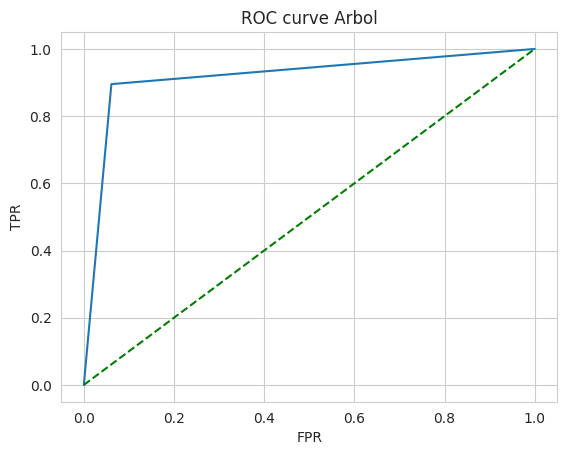


AUC Score para Árbol de Decisión: 0.917057180415318


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Definimos las variables independientes y la variable dependiente
X_2 = df2.drop(['Credit_Score'], axis=1).to_numpy()
y_2 = df2['Credit_Score'].to_numpy()

# Dividimos en sets de entrenamiento y testeo
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=45)

# Entrenamos el modelo y predecimos
dt_roc = tree.DecisionTreeClassifier()
dt_roc.fit(X_train_2, y_train_2)
dt_roc_score = dt_roc.predict_proba(X_test_2)[:,1]


# Calculamos la curva ROC
fpr, tpr, _ = roc_curve(y_test_2, dt_roc_score)

# Visualizamos
plt.plot(fpr, tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve Arbol')
plt.plot([0, 1], [0, 1], color='green', linestyle='--')
plt.show()
print('\nAUC Score para Árbol de Decisión:', roc_auc_score(y_test_2, dt_roc_score))

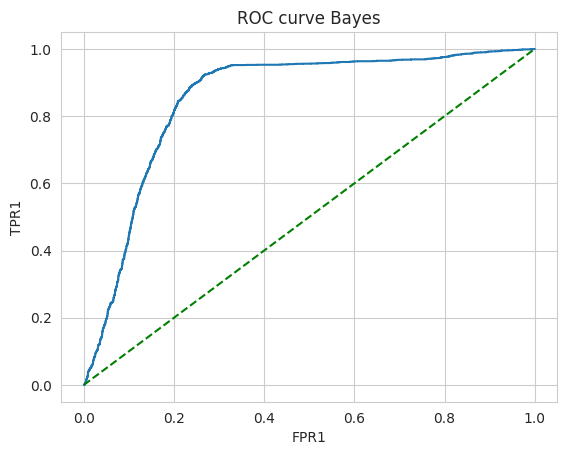


AUC Score para Naives Bayes: 0.8529964229669367


In [ ]:
# Entrenamos el modelo y predecimos
dt_roc = GaussianNB()
dt_roc.fit(X_train_2, y_train_2)
dt_roc_score = dt_roc.predict_proba(X_test_2)[:,1]


# Calculamos la curva ROC
fpr1, tpr1, _ = roc_curve(y_test_2, dt_roc_score)

# Visualizamos
plt.plot(fpr1, tpr1)
plt.xlabel('FPR1')
plt.ylabel('TPR1')
plt.plot([0, 1], [0, 1], color='green', linestyle='--')

plt.title('ROC curve Bayes')
plt.show()
print('\nAUC Score para Naives Bayes:', roc_auc_score(y_test_2, dt_roc_score))

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

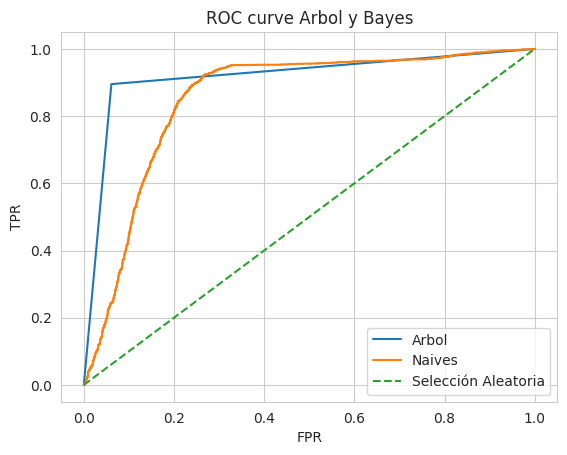

In [ ]:
#A CONTINUACION, PLOTEAMOS LOS DOS GRÁFICOS ANTERIORES PARA REALIZAR UNA MEJOR COMPARACION ENTRE AMBOS MODELOS

fig, ax = plt.subplots()
x = np.linspace(0, 1, 100)
y = x
# Plotear el primer gráfico
ax.plot(fpr, tpr, label='Arbol')

# Plotear el segundo gráfico
ax.plot(fpr1, tpr1, label='Naives')
ax.plot(x, y,linestyle = "--", label='Selección Aleatoria')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve Arbol y Bayes')

# Agregar una leyenda
ax.legend()

# Mostrar el gráfico
plt
